In [1]:
%load_ext autoreload
%autoreload 2
import sys; sys.path.append("..")

import polars as pl
import matplotlib.pyplot as plt
from src.features import add_features, FEATURES

In [2]:
feat = add_features(pl.read_parquet("../data/processed/scoped.parquet"))
print(feat.shape)
feat.select(FEATURES + ["isFraud"]).head()

(2770409, 27)


is_transfer,log_amount,oldbalanceOrg,amt_to_bal,orig_zero_bal,drains_account,is_round,hour,is_night,dest_prior_txn,dest_prior_amt,dest_age_hours,dest_is_new,dest_txn_24h,dest_amt_24h,isFraud
i8,f64,f64,f64,i8,i8,i8,i64,i8,u32,f64,i64,i8,u32,f64,i64
1,5.204007,181.0,0.994505,0,1,0,1,1,0,0.0,0,1,0,0.0,1
0,5.204007,181.0,0.994505,0,1,0,1,1,0,0.0,0,1,0,0.0,1
0,12.342066,15325.0,14.950668,0,1,0,1,1,0,0.0,0,1,0,0.0,0
1,12.27984,705.0,304.972096,0,1,0,1,1,0,0.0,0,1,0,0.0,0
1,12.649754,10835.0,28.763925,0,1,0,1,1,0,0.0,0,1,0,0.0,0


In [3]:
busy = feat.group_by("nameDest").len().sort("len", descending=True)["nameDest"][0]
feat.filter(pl.col("nameDest") == busy).select(
    ["step", "amount", "dest_prior_txn", "dest_txn_24h", "dest_age_hours", "dest_is_new"]
).head(15)

step,amount,dest_prior_txn,dest_txn_24h,dest_age_hours,dest_is_new
i64,f64,u32,u32,i64,i8
1,583848.46,0,0,0,1
1,176334.26,0,0,0,1
1,373068.26,0,0,0,1
1,18288.91,0,0,0,1
1,483544.3,0,0,0,1
…,…,…,…,…,…
1,138647.54,0,0,0,1
1,432168.02,0,0,0,1
2,312856.0,12,12,1,0


In [4]:
feat.group_by("isFraud").agg([pl.col(f).mean() for f in FEATURES]).to_pandas().T

,0,1
isFraud,1.000000e+00,0.000000e+00
is_transfer,4.988433e-01,1.914462e-01
log_amount,1.289203e+01,1.192493e+01
oldbalanceOrg,1.649668e+06,4.287969e+04
amt_to_bal,1.161967e+03,1.581674e+05
orig_zero_bal,4.992086e-03,4.737321e-01
drains_account,9.767442e-01,4.272195e-01
is_round,3.689273e-02,1.080300e-03
hour,1.154645e+01,1.531997e+01
is_night,2.430293e-01,9.437781e-03


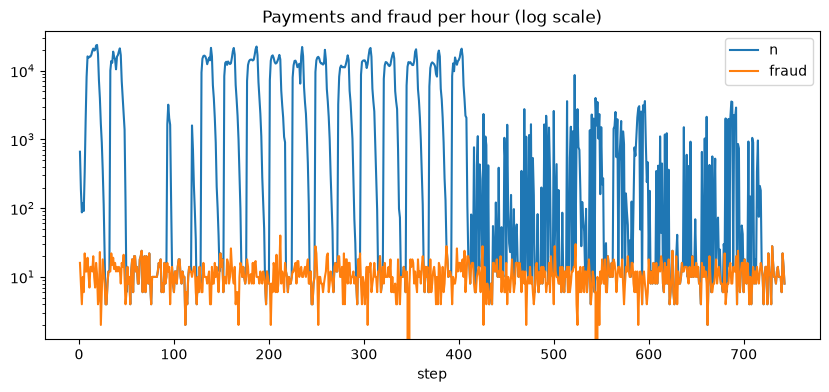

In [5]:
per_step = (feat.group_by("step")
                .agg(n=pl.len(), fraud=pl.col("isFraud").sum())
                .sort("step").to_pandas())
per_step.plot(x="step", y=["n", "fraud"], logy=True, figsize=(10, 4),
              title="Payments and fraud per hour (log scale)")
plt.show()

In [6]:
legit_steps = feat.filter(pl.col("isFraud") == 0)["step"]
TRAIN_END = int(legit_steps.quantile(0.70))
VAL_END   = int(legit_steps.quantile(0.85))
print("TRAIN_END =", TRAIN_END, "  VAL_END =", VAL_END)

train = feat.filter(pl.col("step") <= TRAIN_END)
val   = feat.filter((pl.col("step") > TRAIN_END) & (pl.col("step") <= VAL_END))
test  = feat.filter(pl.col("step") > VAL_END)

for name, d in [("train", train), ("val", val), ("test", test)]:
    print(f"{name:5s}  rows={d.shape[0]:>9,}  fraud={d['isFraud'].sum():>5,}  rate={d['isFraud'].mean():.4f}")

TRAIN_END = 322   VAL_END = 376
train  rows=1,938,484  fraud=3,633  rate=0.0019
val    rows=  415,628  fraud=  560  rate=0.0013
test   rows=  416,297  fraud=4,020  rate=0.0097


In [7]:
feat.write_parquet("../data/processed/features.parquet")
print("Saved!")

Saved!


## Key takeaways
- Built 15 features, all using only information available before each payment.
- Receiver-account history features (prior payments, account age, 24h activity) capture money-mule behaviour.
- Verified there is no future leakage by manually checking the busiest receiving account.
- Time-based split: train ≤ step [322], validation ≤ step [376], test after that.
- Strongest differences between fraud and legit:
  - **oldbalanceOrg:** fraud targets well-funded accounts (average starting balance ~1.65M vs ~43k for legit, ~38x higher).
  - **orig_zero_bal:** ~47% of legit payments come from accounts showing a zero starting balance vs only ~0.5% of fraud. Fraudsters target accounts that have money.
  - **amt_to_bal:** higher on average for legit, but this is driven by the zero-balance accounts (dividing by a near-zero balance inflates the ratio), so it reflects the same pattern rather than a separate one.
  - The share of legit payments from zero-balance accounts is unusually high for real banking and is likely a simulation artefact. I note it as a limitation.

In [8]:
import numpy as np

means = (feat.group_by("isFraud")
             .agg([pl.col(f).mean() for f in FEATURES])
             .sort("isFraud")
             .to_pandas().set_index("isFraud").T)
means.columns = ["legit_avg", "fraud_avg"]

ratio = (means["fraud_avg"] + 1e-9) / (means["legit_avg"] + 1e-9)
means["higher_for"] = np.where(ratio > 1, "fraud", "legit")
means["times_different"] = np.maximum(ratio, 1 / ratio).round(1)
means.sort_values("times_different", ascending=False)

,legit_avg,fraud_avg,higher_for,times_different
amt_to_bal,1.581674e+05,1.161967e+03,legit,136.1
orig_zero_bal,4.737321e-01,4.992086e-03,legit,94.9
oldbalanceOrg,4.287969e+04,1.649668e+06,fraud,38.5
is_round,1.080300e-03,3.689273e-02,fraud,34.2
is_night,9.437781e-03,2.430293e-01,fraud,25.8
dest_amt_24h,3.823523e+05,6.208500e+04,legit,6.2
dest_txn_24h,1.118838e+00,2.102764e-01,legit,5.3
dest_is_new,1.942053e-01,6.725922e-01,fraud,3.5
dest_prior_txn,5.226312e+00,1.763424e+00,legit,3.0
dest_prior_amt,1.646819e+06,5.510257e+05,legit,3.0
